In [3]:
dataset = "C:/projects/motion-capture-project/assets/FT028g/2021-10-06-16-25-40/"

* keepMarker*.h264 son los videos crudos H.264 de cada cámara.
* keepMarker*.seek son archivos auxiliares para hacer seek / navegación rápida dentro del video.}
* frameInfo*.dat son metadatos por cámara y por frame

In [4]:
import pickle

with open(dataset + "metadata.pkl", "rb") as f:
  metadata = pickle.load(f)

metadata

{'cameraModel': 'see3cam_24cug',
 'camCount': 8,
 'camIdList': ['4c08760',
  '3e0f8f0',
  '2b9dc514',
  '969eac0',
  '39e14393',
  '216f21c1',
  '2f1800ef',
  '12b5103c'],
 'frameCountList': [4345, 4345, 4345, 4345, 4345, 4345, 4345, 4345],
 'hardwareTrigger': True,
 'externalPulse': True,
 'turnOnLED': False,
 'showPreview': True,
 'previewDivider': 30,
 'exposure': -8,
 'gain': 6,
 'saveFolderName': '.\\group_2021-10-06-12-00-59/videoRecord/2021-10-06-16-25-40/',
 'saveRaw': True,
 'genSeekTable': True,
 'multipleRecord': None,
 'useClockDividerCircuit': False,
 'refTime': datetime.datetime(2021, 10, 6, 16, 17, 11, 37593),
 'qualisysFrequencyDivisor': 4,
 'arduinoPulseCounter': 4345,
 'startDatetime': datetime.datetime(2021, 10, 6, 17, 1, 2, 383358),
 'stopDatetime': datetime.datetime(2021, 10, 6, 17, 2, 28, 936657),
 'halfExposure': 0.001944,
 'originalGroupPath': '/mnt/nas/root/group_2021-10-06-12-00-59/',
 'originalTsvPath': '/mnt/nas/root/group_2021-10-06-12-00-59/marker/FT028_ma

keepMarker*.h264
-> detectar keypoints 2D por cámara
-> triangulación con calibración
-> trayectorias 3D

**Toda esa información de metadata.pkl corresponde a una única sesión de captura de una persona observada simultáneamente por las 8 cámaras RGB y el sistema Qualisys.**

record = Path(
  "FT028g/2021-10-06-16-25-40"
)

Sujeto:
FT028g

Sesión:
2021-10-06 16:25:40

---

8 videos RGB
+
1 captura Qualisys
+
1 calibración
+
1 sincronización temporal

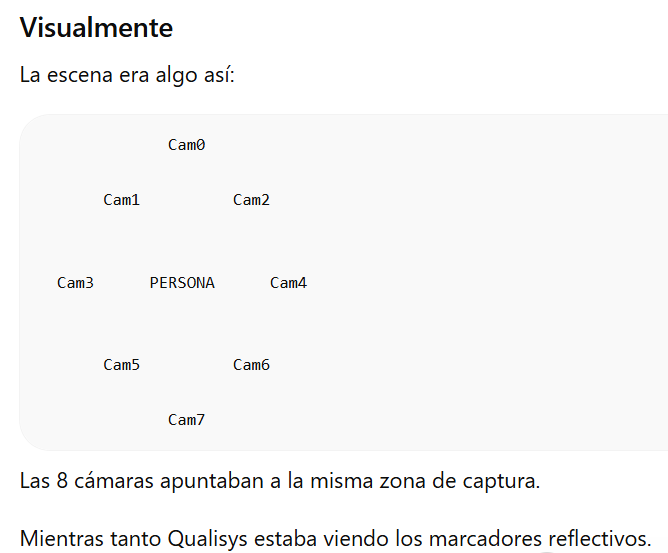
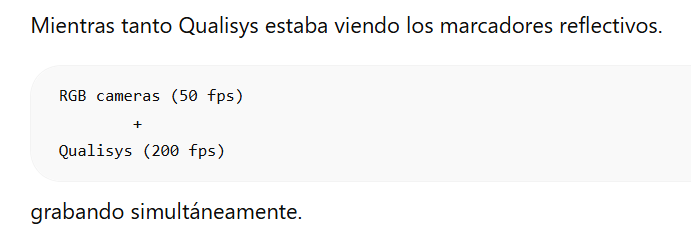
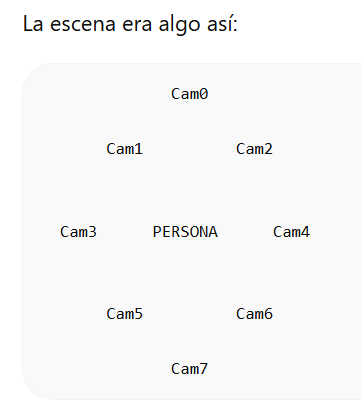

In [5]:
from pathlib import Path
import pickle

record = Path(dataset)

with open(record / "metadata.pkl", "rb") as f:
  metadata = pickle.load(f)

print(type(metadata))
print(metadata)
metadata

<class 'dict'>
{'cameraModel': 'see3cam_24cug', 'camCount': 8, 'camIdList': ['4c08760', '3e0f8f0', '2b9dc514', '969eac0', '39e14393', '216f21c1', '2f1800ef', '12b5103c'], 'frameCountList': [4345, 4345, 4345, 4345, 4345, 4345, 4345, 4345], 'hardwareTrigger': True, 'externalPulse': True, 'turnOnLED': False, 'showPreview': True, 'previewDivider': 30, 'exposure': -8, 'gain': 6, 'saveFolderName': '.\\group_2021-10-06-12-00-59/videoRecord/2021-10-06-16-25-40/', 'saveRaw': True, 'genSeekTable': True, 'multipleRecord': None, 'useClockDividerCircuit': False, 'refTime': datetime.datetime(2021, 10, 6, 16, 17, 11, 37593), 'qualisysFrequencyDivisor': 4, 'arduinoPulseCounter': 4345, 'startDatetime': datetime.datetime(2021, 10, 6, 17, 1, 2, 383358), 'stopDatetime': datetime.datetime(2021, 10, 6, 17, 2, 28, 936657), 'halfExposure': 0.001944, 'originalGroupPath': '/mnt/nas/root/group_2021-10-06-12-00-59/', 'originalTsvPath': '/mnt/nas/root/group_2021-10-06-12-00-59/marker/FT028_marker_0000.tsv'}


{'cameraModel': 'see3cam_24cug',
 'camCount': 8,
 'camIdList': ['4c08760',
  '3e0f8f0',
  '2b9dc514',
  '969eac0',
  '39e14393',
  '216f21c1',
  '2f1800ef',
  '12b5103c'],
 'frameCountList': [4345, 4345, 4345, 4345, 4345, 4345, 4345, 4345],
 'hardwareTrigger': True,
 'externalPulse': True,
 'turnOnLED': False,
 'showPreview': True,
 'previewDivider': 30,
 'exposure': -8,
 'gain': 6,
 'saveFolderName': '.\\group_2021-10-06-12-00-59/videoRecord/2021-10-06-16-25-40/',
 'saveRaw': True,
 'genSeekTable': True,
 'multipleRecord': None,
 'useClockDividerCircuit': False,
 'refTime': datetime.datetime(2021, 10, 6, 16, 17, 11, 37593),
 'qualisysFrequencyDivisor': 4,
 'arduinoPulseCounter': 4345,
 'startDatetime': datetime.datetime(2021, 10, 6, 17, 1, 2, 383358),
 'stopDatetime': datetime.datetime(2021, 10, 6, 17, 2, 28, 936657),
 'halfExposure': 0.001944,
 'originalGroupPath': '/mnt/nas/root/group_2021-10-06-12-00-59/',
 'originalTsvPath': '/mnt/nas/root/group_2021-10-06-12-00-59/marker/FT028_ma

In [6]:
videos = sorted(record.glob("keepMarker*.h264"))

for v in videos:
  print(v.name)

keepMarker12b5103c.h264
keepMarker216f21c1.h264
keepMarker2b9dc514.h264
keepMarker2f1800ef.h264
keepMarker39e14393.h264
keepMarker3e0f8f0.h264
keepMarker4c08760.h264
keepMarker969eac0.h264


In [7]:
import cv2

cap = cv2.VideoCapture(str(videos[0]))

ok, frame = cap.read()

print(ok)
print(frame.shape)

cap.release()

True
(1200, 1920, 3)


In [9]:
%pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 11.9 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.9 MB 2.8 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.9 MB 2.8 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.9 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.9 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.9 MB 1.0 MB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.9 MB 1.0 MB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.9 MB 919.2 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.9 MB 919.2 kB/s eta 0:00:10
   ------- -------------------------------- 1.8/9.9 MB 854.2 kB/s eta 0:00:10
   -------- ------------------------------- 2.1/9.9 MB 821.5 kB/s eta 0:00:10
   -------- ------------------------------- 2.1/9.9 MB 821.5 kB/s eta 0:00:10
   -----


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
tsv_path = record / "qualisys.tsv"

with open(tsv_path, "r", encoding="utf-8", errors="ignore") as f:
  for i in range(40):
    line = f.readline()
    print(i, repr(line))

0 'NO_OF_FRAMES\t17378\n'
1 'NO_OF_CAMERAS\t16\n'
2 'NO_OF_MARKERS\t46\n'
3 'FREQUENCY\t200\n'
4 'NO_OF_ANALOG\t0\n'
5 'ANALOG_FREQUENCY\t0\n'
6 'DESCRIPTION\t--\n'
7 'TIME_STAMP\t2021-10-06, 17:01:35.124\t623682.56988080\n'
8 'DATA_INCLUDED\t3D\n'
9 'MARKER_NAMES\tRTEMP\tRHEAD\tLHEAD\tLTEMP\tRACR\tLACR\tSTER\tXPRO\tC7\tT4\tT8\tT10\tRPSIS\tLPSIS\tRICR\tLICR\tRASIS\tLASIS\tRHME\tRHLE\tRRSP\tRUSP\tRCAP\tRHMC2\tLHME\tLHLE\tLRSP\tLUSP\tLCAP\tLHMC2\tRFME\tRFLE\tRTAM\tRFAL\tRFCC\tRFMT1\tRFMT2\tRFMT5\tLFME\tLFLE\tLTAM\tLFAL\tLFCC\tLFMT1\tLFMT2\tLFMT5\n'
10 'Frame\tTime\tRTEMP X\tRTEMP Y\tRTEMP Z\tRHEAD X\tRHEAD Y\tRHEAD Z\tLHEAD X\tLHEAD Y\tLHEAD Z\tLTEMP X\tLTEMP Y\tLTEMP Z\tRACR X\tRACR Y\tRACR Z\tLACR X\tLACR Y\tLACR Z\tSTER X\tSTER Y\tSTER Z\tXPRO X\tXPRO Y\tXPRO Z\tC7 X\tC7 Y\tC7 Z\tT4 X\tT4 Y\tT4 Z\tT8 X\tT8 Y\tT8 Z\tT10 X\tT10 Y\tT10 Z\tRPSIS X\tRPSIS Y\tRPSIS Z\tLPSIS X\tLPSIS Y\tLPSIS Z\tRICR X\tRICR Y\tRICR Z\tLICR X\tLICR Y\tLICR Z\tRASIS X\tRASIS Y\tRASIS Z\tLASIS X\tLASIS Y\tLASI

In [15]:
df = pd.read_csv(
    tsv_path,
    sep="\t",
    skiprows=10
)

print(df.shape)
print(df.columns[:20])

(17378, 141)
Index(['Frame', 'Time', 'RTEMP X', 'RTEMP Y', 'RTEMP Z', 'RHEAD X', 'RHEAD Y',
       'RHEAD Z', 'LHEAD X', 'LHEAD Y', 'LHEAD Z', 'LTEMP X', 'LTEMP Y',
       'LTEMP Z', 'RACR X', 'RACR Y', 'RACR Z', 'LACR X', 'LACR Y', 'LACR Z'],
      dtype='str')
